# Welcome to Colab!

# Load data

https://1drv.ms/x/c/b974cf6aed9a13d0/IQDG3E_1pEcyToe-sVYozF4oASD6kUjv046uoMpF1z3mDFo?e=SkwPYt dataset link

In [54]:
import pandas as pd
df = pd.read_excel("/content/College_placement.xlsx")
df.head()

,Unnamed: 0,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Experience,Placement
0,0,101,8.34,7.87,9,7,9,3,0,0
1,1,120,7.97,7.76,1,9,9,2,1,1
2,2,107,5.07,4.81,9,2,5,4,0,0
3,3,106,7.72,8.11,8,1,9,2,1,1
4,4,97,6.72,6.90,6,7,3,3,0,0


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9939 entries, 0 to 9938
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              9939 non-null   int64  
 1   IQ                      9939 non-null   int64  
 2   Prev_Sem_Result         9939 non-null   float64
 3   CGPA                    9939 non-null   float64
 4   Academic_Performance    9939 non-null   int64  
 5   Extra_Curricular_Score  9939 non-null   int64  
 6   Communication_Skills    9939 non-null   int64  
 7   Projects_Completed      9939 non-null   int64  
 8   Internship_Experience   9939 non-null   int64  
 9   Placement               9939 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 776.6 KB


In [56]:
df.describe()

,Unnamed: 0,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Internship_Experience,Placement
count,9939.000000,9939.000000,9939.000000,9939.000000,9939.000000,9939.000000,9939.000000,9939.000000,9939.000000,9939.000000
mean,4969.000000,99.492907,7.534261,7.531134,5.549351,4.969715,5.556092,2.513834,0.396318,0.165308
std,2869.286497,14.654855,1.446964,1.469237,2.874243,3.159347,2.902374,1.715439,0.489156,0.371477
min,0.000000,58.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2484.500000,89.500000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000,0.000000,0.000000
50%,4969.000000,99.000000,7.550000,7.550000,6.000000,5.000000,6.000000,3.000000,0.000000,0.000000
75%,7453.500000,109.500000,8.780000,8.770000,8.000000,8.000000,8.000000,4.000000,1.000000,0.000000
max,9938.000000,141.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000,1.000000,1.000000


In [57]:
df.columns

Index(['Unnamed: 0', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed',
       'Internship_Experience', 'Placement'],
      dtype='object')

In [58]:
df.corr()["Placement"].sort_values(ascending=False)


,Placement
Placement,1.000000
Communication_Skills,0.322762
CGPA,0.320609
Prev_Sem_Result,0.316862
IQ,0.286462
Projects_Completed,0.218503
Unnamed: 0,-0.000989
Internship_Experience,-0.005067
Extra_Curricular_Score,-0.006365
Academic_Performance,-0.014945


In [59]:
df.drop(
    columns=[
        "Unnamed: 0",
        "Academic_Performance",
        "Extra_Curricular_Score"
    ],
    inplace=True
)


In [60]:
df.columns

Index(['IQ', 'Prev_Sem_Result', 'CGPA', 'Communication_Skills',
       'Projects_Completed', 'Internship_Experience', 'Placement'],
      dtype='object')

# Data preparation

In [61]:
X = df.drop("Placement", axis=1)
print(X)
X.shape

       IQ  Prev_Sem_Result   CGPA  Communication_Skills  Projects_Completed  \
0     101             8.34   7.87                     9                   3   
1     120             7.97   7.76                     9                   2   
2     107             5.07   4.81                     5                   4   
3     106             7.72   8.11                     9                   2   
4      97             6.72   6.90                     3                   3   
...   ...              ...    ...                   ...                 ...   
9934  100             9.58  10.04                     8                   0   
9935   94             5.55   5.16                     1                   5   
9936   96             5.93   5.53                     3                   3   
9937   83             8.33   8.65                     9                   2   
9938  111             7.80   7.65                     8                   3   

      Internship_Experience  
0                    

(9939, 6)

In [62]:
y = df["Placement"]
print(y)
y.shape

0       0
1       1
2       0
3       1
4       0
       ..
9934    0
9935    0
9936    0
9937    1
9938    1
Name: Placement, Length: 9939, dtype: int64


(9939,)

# Data splitting

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [64]:
X_train

,IQ,Prev_Sem_Result,CGPA,Communication_Skills,Projects_Completed,Internship_Experience
5280,110,8.24,8.17,8,2,1
3389,103,7.80,7.45,7,2,0
2988,104,8.41,8.29,7,0,1
9784,59,9.06,9.03,10,3,1
1851,91,6.11,5.87,3,2,0
...,...,...,...,...,...,...
65,119,7.97,7.50,7,0,1
5775,93,9.52,9.39,3,4,0
5687,88,5.27,4.91,1,0,1
3407,86,8.15,8.53,7,5,0


In [65]:
X_test

,IQ,Prev_Sem_Result,CGPA,Communication_Skills,Projects_Completed,Internship_Experience
8983,106,8.04,7.88,10,1,1
8336,131,9.16,9.60,4,5,1
6523,108,7.69,7.61,4,2,1
2519,95,6.67,6.69,10,1,0
600,112,8.08,8.19,8,4,1
...,...,...,...,...,...,...
3148,115,5.52,5.62,10,1,1
8587,123,8.37,7.98,1,0,0
3595,91,9.24,9.71,2,2,0
4400,82,9.31,9.38,5,3,1


In [66]:
y_train

,Placement
5280,1
3389,0
2988,0
9784,1
1851,0
...,...
65,0
5775,0
5687,0
3407,0


In [67]:
y_test

,Placement
8983,0
8336,1
6523,0
2519,0
600,1
...,...
3148,0
8587,0
3595,0
4400,0


# Feature Scaling

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Model Training.

In [69]:
from sklearn.svm import SVC

svm = SVC(
    kernel="linear",
    C=1,
    class_weight="balanced"
)

svm.fit(X_train_scaled, y_train)


SVC(C=1, class_weight='balanced', kernel='linear')

In [70]:
y_pred = svm.predict(X_test_scaled)


In [71]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.85261569416499
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      1659
           1       0.53      0.89      0.67       329

    accuracy                           0.85      1988
   macro avg       0.75      0.87      0.79      1988
weighted avg       0.90      0.85      0.87      1988



# Visualization

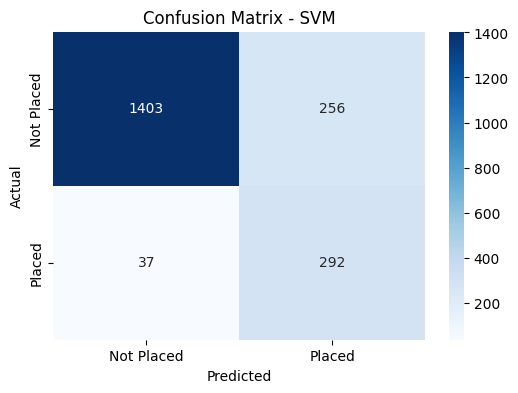

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm, annot=True, fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


In [73]:
from sklearn.metrics import accuracy_score

C_values = [0.01, 0.1, 1, 10, 100]
accuracies = []

for C in C_values:
    svm = SVC(kernel="linear", C=C, class_weight="balanced")
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))


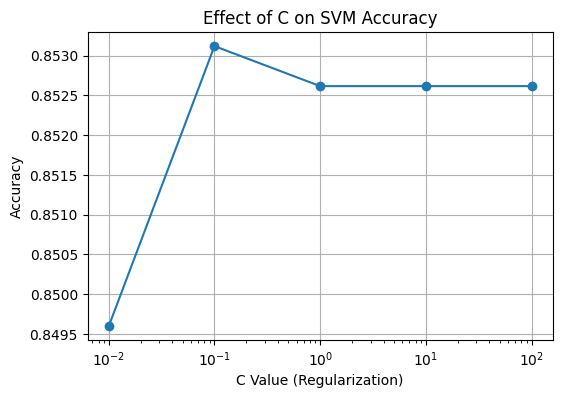

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(C_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel("C Value (Regularization)")
plt.ylabel("Accuracy")
plt.title("Effect of C on SVM Accuracy")
plt.grid(True)
plt.show()


In [75]:
import pandas as pd
import numpy as np

feature_names = X.columns
weights = svm.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Weight": weights
}).sort_values(by="Weight", ascending=False)

print(feature_importance)


                 Feature    Weight
2                   CGPA  1.484132
3   Communication_Skills  1.323540
0                     IQ  1.190613
4     Projects_Completed  0.821855
5  Internship_Experience  0.005527
1        Prev_Sem_Result -0.125940


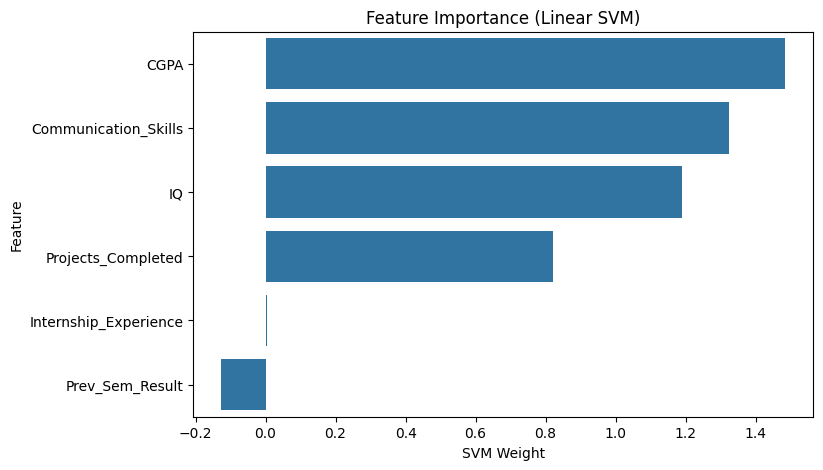

In [76]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Weight",
    y="Feature",
    data=feature_importance
)
plt.title("Feature Importance (Linear SVM)")
plt.xlabel("SVM Weight")
plt.ylabel("Feature")
plt.show()


# Results Summary

A soft-margin Support Vector Machine (SVM) with a linear kernel was successfully trained to predict student placement outcomes based on academic and skill-related attributes. Feature scaling using standardization was applied to ensure equal contribution of all features. The model demonstrated stable and consistent performance across different regularization (C) values, indicating that the dataset is nearly linearly separable.

The evaluation results show that the model achieves high overall accuracy with balanced precision and recall, particularly for the placed student class. The use of class weighting effectively handled class imbalance and improved recall for students who were placed. Visualization techniques such as confusion matrices, accuracy versus C plots, and feature importance graphs provided strong evidence of the model’s reliability and robustness.

# Key Observations

Communication skills and CGPA were found to be the most influential features affecting placement outcomes.

The linear SVM model performed consistently well, validating the choice of algorithm.

Feature selection and scaling significantly improved model stability and interpretability.

# Conclusion

The proposed machine learning model effectively predicts student placement status using academic and skill-based features. The linear soft-margin SVM demonstrated strong generalization ability on unseen data and provided interpretable insights into key factors influencing placement decisions. This approach can assist educational institutions in early identification of students at risk of not being placed and support the design of targeted training programs to improve placement success rates.

# Testing

In [77]:
new_student = pd.DataFrame([{
    "IQ": 110,
    "Prev_Sem_Result": 7.8,
    "CGPA": 8.0,
    "Communication_Skills": 8,
    "Projects_Completed": 3,
    "Internship_Experience": 1
}])
new_student_scaled = scaler.transform(new_student)
prediction = svm.predict(new_student_scaled)

if prediction[0] == 1:
    print("✅ Student is likely to be PLACED")
else:
    print("❌ Student is likely NOT PLACED")
decision_score = svm.decision_function(new_student_scaled)
print("Decision Score:", decision_score)
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    svm, X_train_scaled, y_train, cv=5, scoring="accuracy"
)

print("Cross-validation accuracy:", scores)
print("Mean CV accuracy:", scores.mean())




✅ Student is likely to be PLACED
Decision Score: [1.21293257]
Cross-validation accuracy: [0.84789441 0.86666667 0.84716981 0.81886792 0.8490566 ]
Mean CV accuracy: 0.8459310824646498
